Starting Hyperparameter Fine-Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Hyperparameters Found:
  - n_estimators: 300
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: 0.4
  - max_depth: 15
  - bootstrap: True

--- Tuned Continuous Performance ---
MAE:  6.2668
RMSE: 10.1363
R2:   0.8489

--- Tuned Regulatory Category Classification Report ---
                         precision    recall  f1-score   support

                   Good       0.89      0.91      0.90       230
        Fair / Moderate       0.86      0.85      0.86       179
Unhealthy for Sensitive       0.25      0.14      0.18         7
         Very Unhealthy       0.00      0.00      0.00         3
      Acutely Unhealthy       0.00      0.00      0.00         0
              Emergency       0.00      0.00      0.00         0

               accuracy                           0.87       419
              macro avg       0.33      0.32      0.32       419
           weight

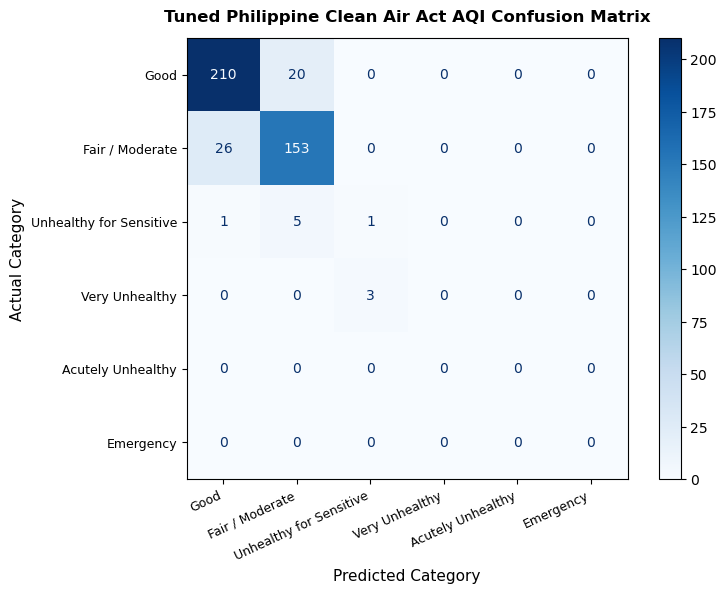


Saved tuned model as fine_tuned_rf_aqi_model.joblib


In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# 1. Load Data
df = pd.read_csv('cleaned_DOAS_urdaneta_2014_2021.csv')
df = df.dropna(subset=['aqi']).copy()
df['date'] = pd.to_datetime(df['date'])
df['dayofweek'] = df['date'].dt.dayofweek

# 2. Features & Target
features = ['month', 'day', 'dayofweek', 'so2', 'nox', 'o3', 'pm10', 'co']
X = df[features].ffill().bfill().fillna(df[features].median())
y = df['aqi']

# 3. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Hyperparameter Search Grid
param_distributions = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [12, 15, 20, 25, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [0.4, 0.5, 0.6, ],
    'bootstrap': [True],
}

base_rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# 5. Execute 5-Fold Randomized Cross-Validation Search
print('Starting Hyperparameter Fine-Tuning...')
tune_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

tune_search.fit(X_train, y_train)

# 6. Extract Best Estimator
best_rf = tune_search.best_estimator_
print('\nBest Hyperparameters Found:')
for param, val in tune_search.best_params_.items():
  print(f'  - {param}: {val}')

# 7. Evaluate Continuous Predictions
y_pred = best_rf.predict(X_test)
print('\n--- Tuned Continuous Performance ---')
print(f'MAE:  {mean_absolute_error(y_test, y_pred):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred):.4f}')
print(f'R2:   {r2_score(y_test, y_pred):.4f}')


# 8. Philippine Clean Air Act Categorization
def to_ph_aqi_category(val):
  if pd.isna(val):
    return None
  elif val <= 50:
    return 'Good'
  elif val <= 100:
    return 'Fair / Moderate'
  elif val <= 150:
    return 'Unhealthy for Sensitive'
  elif val <= 200:
    return 'Very Unhealthy'
  elif val <= 300:
    return 'Acutely Unhealthy'
  else:
    return 'Emergency'


y_test_cat = pd.Series(y_test).apply(to_ph_aqi_category)
y_pred_cat = pd.Series(y_pred).apply(to_ph_aqi_category)

all_categories = [
    'Good',
    'Fair / Moderate',
    'Unhealthy for Sensitive',
    'Very Unhealthy',
    'Acutely Unhealthy',
    'Emergency',
]

print('\n--- Tuned Regulatory Category Classification Report ---')
print(
    classification_report(
        y_test_cat, y_pred_cat, labels=all_categories, zero_division=0
    )
)

# 9. Plot Complete 6x6 Confusion Matrix
cm_tuned = confusion_matrix(y_test_cat, y_pred_cat, labels=all_categories)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned, display_labels=all_categories
)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(
    'Tuned Philippine Clean Air Act AQI Confusion Matrix',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
plt.ylabel('Actual Category', fontsize=11)
plt.xlabel('Predicted Category', fontsize=11)
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.subplots_adjust(bottom=0.25)
plt.savefig('tuned_ph_aqi_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 10. Save Tuned Model
joblib.dump(best_rf, 'fine_tuned_rf_aqi_model.joblib')
print('\nSaved tuned model as fine_tuned_rf_aqi_model.joblib')